<a href="https://colab.research.google.com/github/Tejaswi154/3x3-puzzle-game/blob/master/cifar10_cnn_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision matplotlib

 CIFAR-10 Image Classifier (PyTorch)

Basic CNN model trained on CIFAR-10 dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


We use the CIFAR-10 dataset — 60,000 images across 10 categories (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).

In [ ]:
#Transform- resize->tensor->normalize pixel values
train_transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32,padding=4),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.2
    ),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


In [ ]:
# Download and load training data (50,000 images)
train_data = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

100%|██████████| 170M/170M [00:06<00:00, 24.7MB/s]


In [ ]:
#Download and load test data
test_data=torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)


In [ ]:
# DataLoader: feeds images in batches during training
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=64, shuffle=False
)

In [ ]:
classes = ['airplane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck']

In [ ]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature extraction: finds patterns in images
        self.features = nn.Sequential(
            # Conv layer 1: detects basic edges and colors
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.1),

            # Conv layer 2: detects more complex shapes
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # (16x16 → 8x8)
            nn.Dropout(0.2),

            # Conv layer 3: detects object parts
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2), # (8x8 → 4x4)
            nn.Dropout(0.3),

            # Block 4 — whole object recognition (4×4 → 2×2)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Dropout2d(0.4),
        )


        # Classifier: makes the final prediction
        self.classifier = nn.Sequential(
          nn.Flatten(),           # converts 3D tensor → 1D list of numbers
          nn.Linear(256*2*2, 512),# fully connected layer
          nn.BatchNorm1d(512),
          nn.ReLU(),
          nn.Dropout(0.5),       # randomly drops 50% neurons (prevents overfitting)
          nn.Linear(512, 10)     # 10 outputs = 10 classes

        )

    def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x



In [ ]:
#create the model and move it to the gpu
model=ImageClassifier().to(device)


Logits (raw scores)
   ↓
Softmax → probabilities
   ↓
Pick correct class prob
   ↓
-log(prob)
   ↓
Loss

In [ ]:
# Loss function: measures how wrong the model is
criterion = nn.CrossEntropyLoss()
#optimizers
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Training loop
EPOCHS = 50  # number of times to go through all data

for epoch in range(EPOCHS):
  model.train()
  running_loss=0.0

  for images,labels in train_loader:
    #move data to gpu
    images=images.to(device)
    labels=labels.to(device)

    # 1. clear the old gradients
    optimizer.zero_grad()

    # 2. forward pass
    outputs=model(images)

    #3.calculate the loss
    loss=criterion(outputs,labels)

    #4.backprop- calculate gradients
    loss.backward()

    #5.update weights
    optimizer.step()

    running_loss+=loss.item()

  avg_loss=running_loss/len(train_loader)
  scheduler.step()
  current_lr=scheduler.get_last_lr()[0]

  print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.3f} | {current_lr:.6f}")

Epoch 1/50 — Loss: 1.645 | 0.000999
Epoch 2/50 — Loss: 1.292 | 0.000996
Epoch 3/50 — Loss: 1.138 | 0.000991
Epoch 4/50 — Loss: 1.045 | 0.000984
Epoch 5/50 — Loss: 0.975 | 0.000976
Epoch 6/50 — Loss: 0.929 | 0.000965
Epoch 7/50 — Loss: 0.889 | 0.000952
Epoch 8/50 — Loss: 0.852 | 0.000938
Epoch 9/50 — Loss: 0.827 | 0.000922
Epoch 10/50 — Loss: 0.799 | 0.000905
Epoch 11/50 — Loss: 0.777 | 0.000885
Epoch 12/50 — Loss: 0.763 | 0.000864
Epoch 13/50 — Loss: 0.750 | 0.000842
Epoch 14/50 — Loss: 0.727 | 0.000819
Epoch 15/50 — Loss: 0.711 | 0.000794
Epoch 16/50 — Loss: 0.696 | 0.000768
Epoch 17/50 — Loss: 0.686 | 0.000741
Epoch 18/50 — Loss: 0.675 | 0.000713
Epoch 19/50 — Loss: 0.662 | 0.000684
Epoch 20/50 — Loss: 0.656 | 0.000655
Epoch 21/50 — Loss: 0.639 | 0.000624
Epoch 22/50 — Loss: 0.623 | 0.000594
Epoch 23/50 — Loss: 0.613 | 0.000563
Epoch 24/50 — Loss: 0.606 | 0.000531
Epoch 25/50 — Loss: 0.595 | 0.000500
Epoch 26/50 — Loss: 0.588 | 0.000469
Epoch 27/50 — Loss: 0.579 | 0.000437
Epoch 28/5

In [ ]:
model.eval() #switch off dropout for evaluation
with torch.no_grad():
  #don't calculate gradients saves memory
  correct=0
  total=0
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)
    outputs=model(images)
    #pick the class with highest score
    _, predicted=torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
accuracy=100*correct/total
print(f"Test Accuracy: {accuracy:.2f}%")

#save the trained model
torch.save(model.state_dict(),'image_classifier.pth')
print=("MODEL SAVED")

Test Accuracy: 88.09%


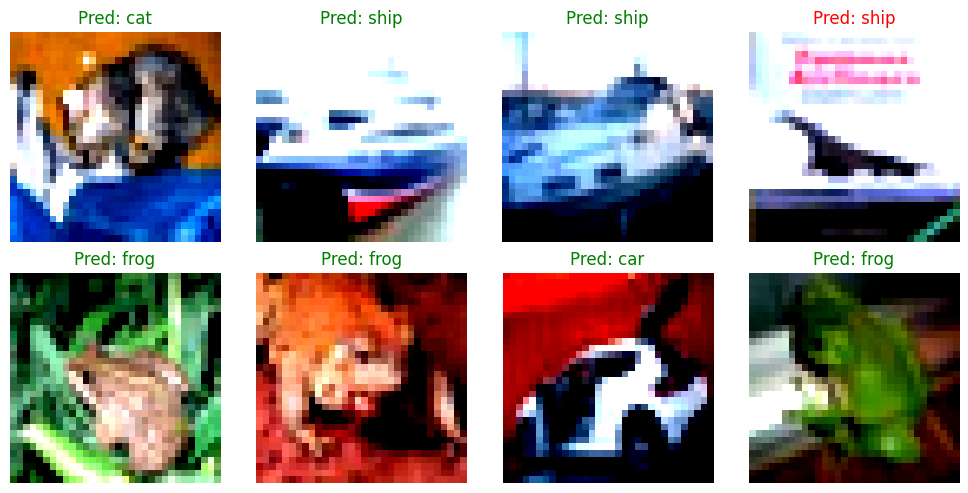

KeyboardInterrupt: Interrupted by user

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
# Option A: predict from test dataset
dataiter=iter(test_loader)
images,labels=next(dataiter)
model.eval()
with torch.no_grad():
  outputs=model(images.to(device))
  _, predicted=torch.max(outputs,1)
# Show first 8 images with predictions
fig,axes=plt.subplots(nrows=2,ncols=4,figsize=(10,5))
for i,ax in enumerate(axes.flat):
  img=images[i]/2+0.5
  ax.imshow(img.permute(1,2,0))
  color = 'green' if predicted[i] == labels[i] else 'red'
  ax.set_title(f"Pred: {classes[predicted[i]]}", color=color)
  ax.axis('off')
plt.tight_layout()
plt.show()


#predict your own image
path=input("Enter image path: ")
img=Image.open(path).resize((32,32))
tensor=transforms(img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(tensor)
    _, pred = torch.max(output, 1)
print(f"Your image is: {classes[pred.item()]}")